In [ ]:
# import of modules
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import soundfile as sf
import math
import seaborn as sns
from scipy import signal
%matplotlib inline

In [3]:
# setting of matplotlib
# font
plt.rcParams['font.family'] = 'Times New Roman'

# font of equation
plt.rcParams['mathtext.fontset'] = 'cm'

# direction of x and y-scales
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# showing of minor x and y-scales
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# showing of scales in all directions
plt.rcParams["xtick.top"] = True
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True
plt.rcParams["ytick.right"] = True

# font size
plt.rcParams["font.size"] = 30

In [4]:
# function of Fourier transform
def fourier_transform(data, samplerate):

    # preprocessing by window function
    N = len(data)
    window = np.hanning(N)
    input_data = data * window
    
    # fast Fourier transform
    spectrum = np.fft.fft(data)
    
    # calculation of amplitude spectrum
    amplitude = np.sqrt((spectrum.real**2) + (spectrum.imag**2)) / (N / 2)
    
    # generalization
    amplitude = 1 / (sum(window) / N) * amplitude
    
    # truncation at Nyquist frequency
    amplitude = amplitude[:int(len(amplitude)/2)]
    
    return amplitude**2

In [5]:
# High pass filter
def highpass_filter(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate / 2
    wp = fp / fn
    ws = fs / fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "high")
    y = signal.filtfilt(b, a, x)
    return y

In [6]:
# Short time Fourier transform
def calc_stft(data, sample_number, samplerate):
    
    # matrix of stft
    stft = []
    
    for i in range(sample_number):
        b1 = i * ((len(data) - sample_number*2) // sample_number)
        b2 = b1 + sample_number*2
        power = fourier_transform(data[b1:b2], samplerate)
        stft.append(power)
        
    return np.array(stft)

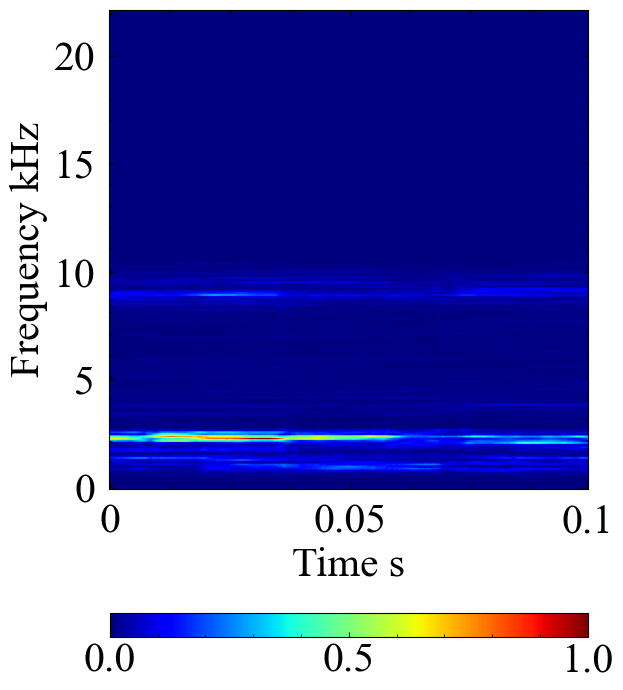

In [7]:
# choosing SNR (please unlock comment out)
SNR = 0
# SNR = -4
# SNR = -8
# SNR = -12
# SNR = -16
# SNR = -20

# choosing data type (please unlock comment out)
data_type = 'water_flow_125'
# data_type = 'gas-liquid_jet_0.15'
# data_type = 'gas-liquid_jet_0.17'
# data_type = 'gas-liquid_jet_0.20'

# filename
filename1 = r"C:\Users\Casper4\Python\ueki\shibasaki\研究\water_flow\water_flow_125.wav"
filename2 = r"C:\Users\Casper4\Python\ueki\shibasaki\研究\Pool_boiling\Subcooling_20_degrees\0.3\2024.11.12_1\録音データ_熱流束\index=23.1.01e+06.wav"

# reading of wav file
data1, samplerate = sf.read(filename1)
data2, samplerate = sf.read(filename2)

# preprocessing by high pass filter
data1 = highpass_filter(data1[:2646000,0], samplerate, 1000, 900, 0.00001, 0.0001)
data2 = highpass_filter(data2[:2646000,0], samplerate, 1000, 900, 0.00001, 0.0001)

# amplify background noise according to SNR
data1_power = sum(data1**2) / len(data1)
data2_power = sum(data2**2) / len(data2)
data1 = data1 * np.sqrt((data2_power / 10 ** (SNR / 10)) / data1_power)

# normal sound -> water flow sound
# anomaly sound -> water flow sound + bubble jet flow sound
if data_type == 'water_flow_125':
    all_data = data2
else:
    all_data = data1 + data2

# segment length
data_length = 4410

# sample number
sample_number = 672

# size of picture (224 pixel × 224 pixel)
number = 224

# extraction of segment and stft
i = 6
start = data_length * i
finish = data_length * (i + 1)
stft = calc_stft(all_data[start:finish], sample_number,samplerate)

# resize into number × number
# matix of compressed stft
stft_comp = np.zeros((number, number))
# extract the maximum value in each interval
interval = int(sample_number / number)
for j in range(number):
    for k in range(number):
        stft_comp[j][k] = np.max(stft[int(j*interval):int((j+1)*interval), int(k*interval):int((k+1)*interval)])
        
# time axis
time_axis = np.linspace(0, 1/samplerate * (data_length - 1), number)
# frequency axis
frequency_axis = np.linspace(0, samplerate/2000, number)

# figure
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111)

# heatmap
im = ax.imshow(np.rot90(stft_comp)/np.max(stft_comp), 
            vmin=0,
            vmax=1,
            cmap='jet')

# x-label and y-label
ax.set_xlabel('Time s')
ax.set_ylabel('Frequency kHz')

# x-scales
x_label = [0, 0.05, 0.1]
x_position = [np.argmin(np.abs(d - time_axis)) for d in x_label]
plt.xticks(x_position, x_label)

# y-scales
y_label = [0, 5, 10, 15, 20]
y_position = [(224 - 1) - np.argmin(np.abs(d - frequency_axis)) for d in y_label]
plt.yticks(y_position, y_label)

# space between scale and plot area
ax.tick_params(pad=10)

# colorbar
plt.colorbar(im, ticks=[0, 0.5, 1.0], pad=0.175, shrink=0.525, orientation='horizontal')

plt.tight_layout()
plt.show()